# Assignment 2 — Part A: Meridian Retail

**Outliers and Distribution Shape — Daily Store Sales**


In [ ]:
# Setup — imports and raw-file locations
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from dateutil import parser
from pathlib import Path

# Locate the raw CSV files. Keep them in the same working folder as the notebook.
def find_file(key):
    matches = list(Path('.').glob(f'*{key}*.csv')) + list(Path('/mnt/data').glob(f'*{key}*.csv'))
    if not matches:
        raise FileNotFoundError(f'Could not find CSV containing: {key}')
    return str(matches[0])

MERIDIAN_FILE = find_file('meridian_daily_sales_raw')
SUVIDHA_FILE = find_file('suvidha_loan_predictions_raw')
print('Meridian:', MERIDIAN_FILE)
print('Suvidha :', SUVIDHA_FILE)


## Part A — Q1. Load the file; print shape and dtypes


In [2]:
# Q1 — Code
df = pd.read_csv(MERIDIAN_FILE)
print('Shape:', df.shape)
print(); print('Dtypes:')
print(df.dtypes)

Shape: (1627, 10)

Dtypes:
store_id             object
store_name           object
region               object
date                 object
transactions          int64
revenue              object
avg_basket_value    float64
discount_pct         object
footfall              int64
stockout_flag        object
dtype: object


**Q1 — Interpretation:** The raw file has **1,627 rows and 10 columns**. Several analytically numeric fields are still text (`revenue`, `discount_pct`) because the export contains currency symbols/text and messy values, so cleaning is necessary before statistics.

## Part A — Q2. Standardize store_id, store_name, and region


In [3]:
# Q2 — Code
for c in ['store_id','store_name','region']:
    df[c] = df[c].astype(str).str.strip()
df['store_id'] = df['store_id'].str.upper()
df['store_name'] = df['store_name'].str.title()
df['region'] = df['region'].str.title()
print(df[['store_id','store_name','region']].drop_duplicates().sort_values('store_id').head(20).to_string(index=False))

store_id       store_name region
   ST-01  Riverside Plaza  North
   ST-02     Harbor Point  North
   ST-03   Maple Junction  North
   ST-04  Silverline Mall  North
   ST-05  Eastgate Center  North
   ST-06   Cedar Crossing  North
   ST-07 Sunset Boulevard  South
   ST-08     Palm Terrace  South
   ST-09 Coral Bay Outlet  South
   ST-10  Magnolia Square  South
   ST-11     Willow Creek  South
   ST-12 Bayfront Commons  South
   ST-13   Highland Court   West
   ST-14    Golden Valley   West
   ST-15   Pinecrest Mall   West
   ST-16  Redwood Station   West
   ST-17    Summit Corner   West
   ST-18   Ashbrook Plaza   West


**Q2 — Interpretation:** The categorical labels are now consistent, preventing false groups such as `South`, `SOUTH`, and `south` from being treated separately.

## Part A — Q3. Parse date into a real date column

In [4]:
# Q3 — Code
def parse_mixed_date(x):
    return pd.Timestamp(parser.parse(str(x), dayfirst=True))
df['date'] = df['date'].apply(parse_mixed_date)
print('Unparsed dates:', df['date'].isna().sum())
print('Date range:', df['date'].min().date(), 'to', df['date'].max().date())
print(df['date'].head())

Unparsed dates: 0
Date range: 2026-01-03 to 2026-12-05
0   2026-03-07
1   2026-05-27
2   2026-05-24
3   2026-04-20
4   2026-03-04
Name: date, dtype: datetime64[ns]


**Q3 — Interpretation:** All dates parse successfully under the stated DD/MM/YYYY assumption for ambiguous slash dates. The important point is that the assumption is explicit rather than silently guessed.

## Part A — Q4. Report missing values and clean revenue

In [5]:
# Q4 — Code
print('Missing values BEFORE revenue cleaning:')
print(df.isna().sum())
df['revenue'] = pd.to_numeric(
    df['revenue'].astype(str)
      .str.replace(r'[$,]', '', regex=True)
      .str.replace(r'INR\s*', '', regex=True),
    errors='coerce'
)
print(); print('Revenue dtype:', df['revenue'].dtype)
print('Missing revenue after conversion:', df['revenue'].isna().sum())
print(df['revenue'].head(10))

Missing values BEFORE revenue cleaning:
store_id             0
store_name           0
region               0
date                 0
transactions         0
revenue             53
avg_basket_value     0
discount_pct         0
footfall             0
stockout_flag        0
dtype: int64

Revenue dtype: float64
Missing revenue after conversion: 53
0        NaN
1    4040.14
2    7132.47
3    9117.12
4    2733.73
5    5827.13
6    6733.38
7    8701.50
8    4037.40
9    3676.65
Name: revenue, dtype: float64


**Q4 — Interpretation:** There are **53 missing revenue values**. Currency-decorated values are converted to numeric magnitudes; missing values are kept as `NaN` so later statistics exclude them without fabricating sales. The `INR` label is treated as dirty text in this synthetic audit column rather than applying an unsupported exchange-rate conversion.

## Part A — Q5. Standardize stockout_flag to boolean

In [6]:
# Q5 — Code
flag_map = {'y':True,'yes':True,'1':True,'true':True,'n':False,'no':False,'0':False,'false':False}
print('Raw values:', sorted(pd.read_csv(MERIDIAN_FILE)['stockout_flag'].astype(str).unique()))
df['stockout_flag'] = df['stockout_flag'].astype(str).str.strip().str.lower().map(flag_map)
print('Clean values:', df['stockout_flag'].unique())
print(df['stockout_flag'].value_counts(dropna=False))

Raw values: ['0', '1', 'FALSE', 'N', 'TRUE', 'Y', 'no', 'yes']
Clean values: [False  True]
stockout_flag
False    1132
True      495
Name: count, dtype: int64


**Q5 — Interpretation:** The stockout field is reduced to a consistent boolean variable, so counts and filters are reliable.

## Part A — Q6. Find and remove duplicate ST-11 week

In [7]:
# Q6 — Code
before = len(df)
dup_mask = df.duplicated(subset=list(df.columns), keep='first')
print('Duplicate rows detected:', dup_mask.sum())
print(df.loc[dup_mask, ['store_id','store_name','date']].sort_values('date').to_string(index=False))
df = df.loc[~dup_mask].copy()
print('Rows before:', before)
print('Rows after :', len(df))

Duplicate rows detected: 7
store_id   store_name       date
   ST-11 Willow Creek 2026-03-09
   ST-11 Willow Creek 2026-03-10
   ST-11 Willow Creek 2026-03-11
   ST-11 Willow Creek 2026-03-13
   ST-11 Willow Creek 2026-03-14
   ST-11 Willow Creek 2026-08-03
   ST-11 Willow Creek 2026-12-03
Rows before: 1627
Rows after : 1620


**Q6 — Interpretation:** Exactly **7 duplicate rows** are detected and removed, reducing the dataset from **1,627 to 1,620 rows**. Standardizing `store_name` first is what makes the casing-different duplicate block detectable.

## Part A — Q7. Flag invalid transactions and discount percentages

In [8]:
# Q7 — Code
df['discount_pct'] = pd.to_numeric(df['discount_pct'], errors='coerce')
invalid_tx = df['transactions'] < 0
invalid_discount = df['discount_pct'].notna() & ~df['discount_pct'].between(0,100)
print('Invalid transactions:', invalid_tx.sum())
print('Invalid discounts   :', invalid_discount.sum())
df.loc[invalid_tx, 'transactions'] = np.nan
df.loc[invalid_discount, 'discount_pct'] = np.nan

Invalid transactions: 14
Invalid discounts   : 39


**Q7 — Interpretation:** There are **14 negative transaction counts** and **39 out-of-range discount values**. They are set to missing rather than capped because capping would create artificial observations, while dropping entire rows would unnecessarily discard valid revenue/footfall information.

## Part A — Q8. Save cleaned CSV and report final row count

In [9]:
# Q8 — Code
CLEAN_MERIDIAN = 'meridian_daily_sales_cleaned.csv'
df.to_csv(CLEAN_MERIDIAN, index=False)
print('Saved:', CLEAN_MERIDIAN)
print('Final row count:', len(df))

Saved: meridian_daily_sales_cleaned.csv
Final row count: 1620


**Q8 — Interpretation:** The cleaned Meridian file contains **1,620 rows**. The duplicate week is removed while rows containing field-level data errors are retained with those specific invalid fields marked missing.

## Part A — Q9. Compute Q1, Q2, Q3 and IQR for revenue

In [10]:
# Q1 — Code
rev = df['revenue'].dropna()
Q1, Q2, Q3 = rev.quantile([0.25,0.50,0.75])
IQR = Q3-Q1
print(f'Global Q1={Q1:.2f}, Median={Q2:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}')

sample = np.sort(df.loc[df['store_id']=='ST-01','revenue'].dropna().to_numpy())
def manual_linear_quantile(arr, q):
    pos=(len(arr)-1)*q; lo=int(np.floor(pos)); hi=int(np.ceil(pos)); frac=pos-lo
    return arr[lo] if lo==hi else arr[lo] + frac*(arr[hi]-arr[lo])
for qv in [0.25,0.50,0.75]:
    manual=manual_linear_quantile(sample,qv)
    pandas=pd.Series(sample).quantile(qv)
    print(f'ST-01 q={qv:.2f}: manual={manual:.2f}, pandas={pandas:.2f}')

Global Q1=3587.53, Median=4914.94, Q3=6912.24, IQR=3324.71
ST-01 q=0.25: manual=4005.52, pandas=4005.52
ST-01 q=0.50: manual=5283.30, pandas=5283.30
ST-01 q=0.75: manual=6807.04, pandas=6807.04


**Q1 — Interpretation:** Revenue has **Q1 = 3,587.53, median = 4,914.94, Q3 = 6,912.24, IQR = 3,324.71**. The ST-01 hand calculation matches Pandas, confirming the quartile method used in the notebook.

## Part A — Q10. Compute 1.5×IQR revenue fences

In [11]:
# Q1 — Code
lower_rev = Q1 - 1.5*IQR
upper_rev = Q3 + 1.5*IQR
print(f'Lower fence: {lower_rev:.2f}')
print(f'Upper fence: {upper_rev:.2f}')

Lower fence: -1399.54
Upper fence: 11899.30


**Q1 — Interpretation:** The revenue fences are approximately **−1,399.54 to 11,899.30**. Because daily revenue cannot normally be negative, the practically relevant flags are almost entirely above the upper fence.

## Part A — Q11. List revenue outlier rows

In [12]:
# Q11 — Code
revenue_outliers = df[(df['revenue']<lower_rev) | (df['revenue']>upper_rev)].copy()
print('Outlier count:', len(revenue_outliers))
print(revenue_outliers[['store_id','store_name','region','date','revenue']].sort_values('revenue').to_string(index=False))

Outlier count: 68
store_id       store_name region       date  revenue
   ST-07 Sunset Boulevard  South 2026-04-26 11911.44
   ST-12 Bayfront Commons  South 2026-04-03 11914.65
   ST-12 Bayfront Commons  South 2026-03-13 11928.39
   ST-07 Sunset Boulevard  South 2026-05-15 11969.07
   ST-02     Harbor Point  North 2026-03-04 12008.83
   ST-02     Harbor Point  North 2026-05-24 12016.48
   ST-17    Summit Corner   West 2026-04-17 12040.01
   ST-02     Harbor Point  North 2026-03-31 12052.49
   ST-11     Willow Creek  South 2026-03-10 12054.82
   ST-16  Redwood Station   West 2026-03-23 12127.89
   ST-03   Maple Junction  North 2026-03-23 12145.00
   ST-01  Riverside Plaza  North 2026-07-04 12183.51
   ST-07 Sunset Boulevard  South 2026-04-23 12198.56
   ST-16  Redwood Station   West 2026-04-21 12336.35
   ST-03   Maple Junction  North 2026-05-20 12347.36
   ST-17    Summit Corner   West 2026-03-28 12487.94
   ST-06   Cedar Crossing  North 2026-05-21 12522.55
   ST-09 Coral Bay Outlet  S

**Q11 — Interpretation:** The global revenue fence flags **68 store-days**. These should be investigated as exceptional observations, but a statistical flag alone does not prove the sale is erroneous.

## Part A — Q12. Apply IQR fences to footfall

In [13]:
# Q1 — Code
fQ1, fQ3 = df['footfall'].quantile([0.25,0.75]); fIQR=fQ3-fQ1
lower_foot=fQ1-1.5*fIQR; upper_foot=fQ3+1.5*fIQR
foot_outliers=df[(df['footfall']<lower_foot)|(df['footfall']>upper_foot)]
print(f'Footfall Q1={fQ1:.2f}, Q3={fQ3:.2f}, IQR={fIQR:.2f}')
print(f'Fences: {lower_foot:.2f} to {upper_foot:.2f}')
print('Outlier count:', len(foot_outliers))
print(foot_outliers[['store_id','date','footfall']].sort_values('footfall').to_string(index=False))

Footfall Q1=495.75, Q3=700.25, IQR=204.50
Fences: 189.00 to 1007.00
Outlier count: 9


store_id       date  footfall
   ST-15 2026-04-17       121
   ST-06 2026-04-16       165
   ST-02 2026-04-21       185
   ST-14 2026-03-24      1033
   ST-14 2026-05-10      1045
   ST-06 2026-03-24      1083
   ST-09 2026-03-15     39530
   ST-09 2026-05-21     41562
   ST-09 2026-03-04     41631


**Q1 — Interpretation:** The footfall fences are **189 to 1,007**, and **9 rows** are flagged. The three ~40,000 ST-09 readings are clearly detected, along with several less-extreme low/high observations.

## Part A — Q13. Draw revenue box plot by region

/tmp/ipykernel_683/3109713637.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df.loc[df['region']==r,'revenue'].dropna() for r in regions], labels=regions)


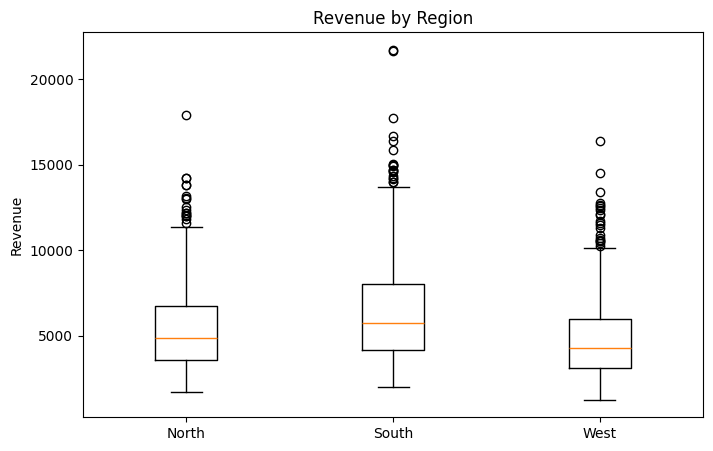

region
South    3854.825
North    3157.880
West     2828.205
Name: revenue, dtype: float64


In [14]:
# Q13 — Code
regions=sorted(df['region'].dropna().unique())
plt.figure(figsize=(8,5))
plt.boxplot([df.loc[df['region']==r,'revenue'].dropna() for r in regions], labels=regions)
plt.ylabel('Revenue'); plt.title('Revenue by Region'); plt.show()
region_iqr=df.groupby('region')['revenue'].apply(lambda s:s.quantile(.75)-s.quantile(.25)).sort_values(ascending=False)
print(region_iqr)

**Q13 — Interpretation:** **South has the widest IQR (≈ 3,854.83)**. In plain English, the middle half of South-region daily revenues varies more widely than the middle half in North or West.

## Part A — Q14. Explain a consistently high store not flagged by IQR

In [15]:
# Q14 — Code
tmp=df.assign(global_revenue_outlier=(df['revenue']<lower_rev)|(df['revenue']>upper_rev))
store_summary=tmp.groupby(['store_id','store_name']).agg(mean_revenue=('revenue','mean'),median_revenue=('revenue','median'),outlier_days=('global_revenue_outlier','sum'))
print(store_summary[store_summary['outlier_days']==0].sort_values('mean_revenue',ascending=False).head())

                          mean_revenue  median_revenue  outlier_days
store_id store_name                                                 
ST-13    Highland Court    5112.438941         5043.15             0
ST-10    Magnolia Square   4743.210682         4438.76             0
ST-05    Eastgate Center   4509.656932         4262.25             0
ST-08    Palm Terrace      4157.031609         3662.00             0
ST-04    Silverline Mall   3856.256667         3353.20             0


**Q14 — Interpretation:** Among stores with zero global flags, **ST-13 (Highland Court)** has the highest mean revenue (about **5,112.44**). Consistently high values can still lie inside the broad population fence; that is generally **correct IQR behavior**, not automatically a false negative, because the rule is designed for isolated extremes rather than business-performance ranking.

## Part A — Q15. Recompute footfall fences after sensor-fault removal

In [16]:
# Q1 — Code
foot_no_sensor=df.loc[df['footfall']<10000,'footfall']
nQ1,nQ3=foot_no_sensor.quantile([.25,.75]); nIQR=nQ3-nQ1
new_lower=nQ1-1.5*nIQR; new_upper=nQ3+1.5*nIQR
print(f'Before: lower={lower_foot:.2f}, upper={upper_foot:.2f}')
print(f'After : lower={new_lower:.2f}, upper={new_upper:.2f}')
print(f'Shift : lower={new_lower-lower_foot:.2f}, upper={new_upper-upper_foot:.2f}')

Before: lower=189.00, upper=1007.00
After : lower=187.50, upper=1007.50
Shift : lower=-1.50, upper=0.50


**Q1 — Interpretation:** The fences shift only slightly, from **189–1,007** to about **187.5–1,007.5**. This demonstrates a strength of quartiles: a few very extreme observations have little effect on IQR-based fences compared with mean/standard-deviation methods.

## Part A — Q16. Recommend treatment of revenue outliers for board reporting

In [17]:
# Q16 — Code
print('Revenue observations used:', rev.size)
print('Revenue outliers:', len(revenue_outliers))
print('Upper fence:', round(upper_rev,2))
print('Outlier share (%):', round(100*len(revenue_outliers)/rev.size,2))

Revenue observations used: 1567
Revenue outliers: 68
Upper fence: 11899.3
Outlier share (%): 4.34


**Q16 — Interpretation:** Meridian should **not automatically delete the 68 flagged revenue days (≈4.34% of non-missing revenue observations)**. First validate them against store records; genuine promotion/event days should remain in the audit trail but be reported separately or alongside robust statistics. Confirmed data errors should be corrected/excluded. For the board deck, show the median and IQR together with a note on exceptional high-revenue days so the headline is not dominated by a small tail.

## Part A — Q17. Compute mean, median, and mode of revenue

In [18]:
# Q17 — Code
mean_rev=rev.mean(); median_rev=rev.median(); modes=rev.mode()
print(f'Mean: {mean_rev:.2f}')
print(f'Median: {median_rev:.2f}')
print('Mode values (first 10):', modes.head(10).tolist())
print('Number of modal values:', len(modes))

Mean: 5613.18
Median: 4914.94
Mode values (first 10): [3258.0, 4175.45, 4287.0, 5344.68]
Number of modal values: 4


**Q17 — Interpretation:** The **mean (≈5,613.18) is above the median (4,914.94)**, which suggests a right-skewed distribution. The data do not have one especially informative unique mode, so mean-versus-median is the more useful ordering here.

## Part A — Q18. Compute revenue skewness

In [19]:
# Q18 — Code
revenue_skew=rev.skew()
print('Revenue skewness:', revenue_skew)

Revenue skewness: 1.383438225562043


**Q18 — Interpretation:** Revenue skewness is approximately **+1.383**, indicating **strong positive/right skew** under a common rule of thumb (>1 in absolute value = strong). High-revenue days stretch the right tail.

## Part A — Q19. Plot revenue histogram with mean and median

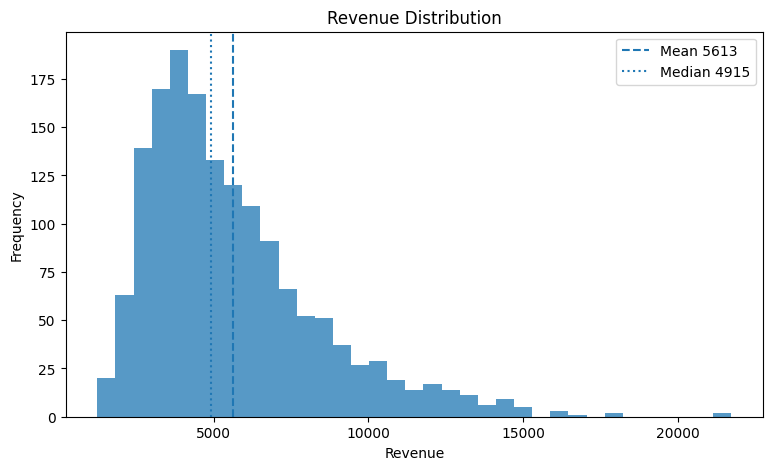

In [20]:
# Q19 — Code
plt.figure(figsize=(9,5))
plt.hist(rev, bins=35, alpha=.75)
plt.axvline(mean_rev, linestyle='--', label=f'Mean {mean_rev:.0f}')
plt.axvline(median_rev, linestyle=':', label=f'Median {median_rev:.0f}')
plt.xlabel('Revenue'); plt.ylabel('Frequency'); plt.title('Revenue Distribution'); plt.legend(); plt.show()

**Q17 — Interpretation:** The histogram shows a longer upper-revenue tail, and the mean sits to the right of the median. This visually agrees with Q17–Q18’s right-skew conclusion.

## Part A — Q20. Choose mean or median for the board headline

In [21]:
# Q20 — Code
print(f'Mean={mean_rev:.2f}, Median={median_rev:.2f}, Skew={revenue_skew:.3f}')

Mean=5613.18, Median=4914.94, Skew=1.383


**Q20 — Interpretation:** The **median (4,914.94)** is the fairer single-number description of a typical daily revenue in this strongly right-skewed dataset. The mean (5,613.18) is pulled upward by the high-revenue tail, so using it alone can make a typical day appear stronger than it is.

## Part A — Q21. Compare footfall skewness before/after sensor faults

In [22]:
# Q21 — Code
foot_skew_before=df['footfall'].skew(); foot_skew_after=foot_no_sensor.skew()
print(f'Before removal: {foot_skew_before:.4f}')
print(f'After removal : {foot_skew_after:.4f}')
print(f'Change        : {foot_skew_after-foot_skew_before:.4f}')

Before removal: 22.9566
After removal : 0.0254
Change        : -22.9312


**Q21 — Interpretation:** Footfall skewness falls from about **22.957** to **0.025** after removing the three sensor-fault days. The raw shape therefore looked extremely right-skewed almost entirely because of faulty readings.

## Part A — Q22. Explain “right-skewed” to a non-technical manager

In [23]:
# Q22 — Code
print(f'Median revenue: {median_rev:.2f}')
print(f'Mean revenue  : {mean_rev:.2f}')

Median revenue: 4914.94
Mean revenue  : 5613.18


**Q22 — Interpretation:** “Right-skewed” means most store-days are concentrated around ordinary revenue levels, while a smaller number of unusually high-revenue days stretch the distribution upward. Here the typical middle value is about **4,914.94**, but those high days pull the arithmetic average up to about **5,613.18**. So the average is higher than what a typical day actually looks like.

## Part A — Q23. Region table: median, IQR, outlier count

In [24]:
# Q23 — Code
def region_stats(g):
    s=g['revenue'].dropna(); q1=s.quantile(.25); q3=s.quantile(.75); i=q3-q1
    out=((s<q1-1.5*i)|(s>q3+1.5*i)).sum()
    return pd.Series({'median_revenue':s.median(),'IQR':i,'outlier_count':out})
region_table=df.groupby('region').apply(region_stats, include_groups=False)
print(region_table.round(2))

        median_revenue      IQR  outlier_count
region                                        
North          4861.09  3157.88           17.0
South          5759.32  3854.82           19.0
West           4287.35  2828.20           21.0


**Q23 — Interpretation:** Regional results are: **North median 4,861.09, IQR 3,157.88, 17 outliers; South median 5,759.32, IQR 3,854.83, 19 outliers; West median 4,287.35, IQR 2,828.21, 21 outliers**. Note that these outlier counts use each region’s own fences.

## Part A — Q24. Which region should Finance investigate first?

In [25]:
# Q24 — Code
print(region_table.round(2).sort_values(['outlier_count','IQR'], ascending=False))

        median_revenue      IQR  outlier_count
region                                        
West           4287.35  2828.20           21.0
South          5759.32  3854.82           19.0
North          4861.09  3157.88           17.0


**Q24 — Interpretation:** **West has the largest region-specific outlier count (21)**, while **South has the widest IQR (3,854.83)**. For an outlier-focused audit, West is the first region to inspect because it produces the most days outside its own regional fence; Finance should separately note South’s greater day-to-day middle-spread variability.

## Part A — Q25. Executive summary

In [26]:
# Q25 — Code
summary = f"""After cleaning, Meridian's dataset contains {len(df):,} rows, with seven duplicated ST-11 records removed and invalid transaction/discount entries isolated as missing. Revenue is strongly right-skewed (skew {revenue_skew:.2f}), with a median of {median_rev:,.2f} versus a higher mean of {mean_rev:,.2f}. The global 1.5×IQR rule flags {len(revenue_outliers)} revenue days above/below fences of {lower_rev:,.2f} and {upper_rev:,.2f}. Footfall analysis identifies the three ~40,000 readings as sensor faults; removing them reduces skew from {foot_skew_before:.2f} to {foot_skew_after:.2f}. South has the widest regional revenue IQR, while West has the largest region-specific revenue-outlier count. For board reporting, Meridian should emphasize median revenue and IQR, validate exceptional days separately, and avoid deleting statistically flagged revenue without business verification."""
print(summary)

After cleaning, Meridian's dataset contains 1,620 rows, with seven duplicated ST-11 records removed and invalid transaction/discount entries isolated as missing. Revenue is strongly right-skewed (skew 1.38), with a median of 4,914.94 versus a higher mean of 5,613.18. The global 1.5×IQR rule flags 68 revenue days above/below fences of -1,399.54 and 11,899.30. Footfall analysis identifies the three ~40,000 readings as sensor faults; removing them reduces skew from 22.96 to 0.03. South has the widest regional revenue IQR, while West has the largest region-specific revenue-outlier count. For board reporting, Meridian should emphasize median revenue and IQR, validate exceptional days separately, and avoid deleting statistically flagged revenue without business verification.


**Q25 — Interpretation:** The executive summary ties the statistical results directly to reporting and data-quality decisions: robust center (median), exceptional-day validation, and explicit treatment of sensor faults.